<a href="https://colab.research.google.com/github/Shorovpaul/Performance-and-Explainability-Behavior-of-Ensemble-Machine-Learning-Models-on-Healthcare-01-/blob/main/XGES_tech_mental_health_burnout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn imbalanced-learn shap xgboost

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("tech_mental_health_burnout.csv")

data['Class'] = data['burnout_level'].apply(lambda x: 0 if x == 'Low' else 1)

X = data.drop(['burnout_level', 'burnout_score', 'Class'], axis=1)
y = data['Class']

X = pd.get_dummies(X, drop_first=True)

print(f"Dataset shape after encoding: {X.shape}")
print(y.value_counts())

Dataset shape after encoding: (150000, 33)
Class
0    131620
1     18380
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Balanced class counts:")
print(y_train_bal.value_counts())

Balanced class counts:
Class
0    105296
1    105296
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, max_iter=500),
    "XGB": xgb.XGBClassifier(eval_metric="logloss")
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    if name in ["SVM", "KNN"]:
        model.fit(X_train_bal_scaled[:10000], y_train_bal[:10000])
    else:
        model.fit(X_train_bal_scaled, y_train_bal)
    trained_models[name] = model

Training LR...
Training RF...
Training GB...
Training KNN...
Training SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training XGB...


In [ ]:
from sklearn.metrics import average_precision_score

model_scores = {}

for name, model in trained_models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    score = average_precision_score(y_test, probs)
    model_scores[name] = score

print("\nAUPRC Scores:", model_scores)

selected_models = {name: model for name, model in trained_models.items() if model_scores[name] > 0.70}


AUPRC Scores: {'LR': np.float64(0.7621593935837709), 'RF': np.float64(0.7406764012629331), 'GB': np.float64(0.7633578981420049), 'KNN': np.float64(0.46858985758297383), 'SVM': np.float64(0.6743629508023752), 'XGB': np.float64(0.7828510982590078)}


In [ ]:
import shap
import numpy as np

explanations = {}

background_sample = X_train_bal_scaled[:500]

for name, model in selected_models.items():
    print(f"Generating SHAP for {name}...")

    if name in ["RF", "GB", "XGB"]:
        explainer = shap.TreeExplainer(model)
        vals = explainer.shap_values(X_test_scaled[:100])
    else:
        explainer = shap.KernelExplainer(model.predict_proba, background_sample)
        vals = explainer.shap_values(X_test_scaled[:100])

    if isinstance(vals, list):

        importance = np.abs(vals[1]).mean(axis=0)

    elif len(np.array(vals).shape) == 3:

        importance = np.abs(vals[:, :, 1]).mean(axis=0)

    else:
        importance = np.abs(vals).mean(axis=0)

    explanations[name] = importance.flatten()

print("SHAP processing complete. All feature vectors are now standardized.")

Generating SHAP for LR...


  0%|          | 0/100 [00:00<?, ?it/s]

Generating SHAP for RF...
Generating SHAP for GB...
Generating SHAP for XGB...
SHAP processing complete. All feature vectors are now standardized.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

explanations_standardized = {}
for name, importance in explanations.items():

    explanations_standardized[name] = np.array(importance).flatten()


diversity_scores = {}
names = list(explanations_standardized.keys())

for i in range(len(names)):
    for j in range(i+1, len(names)):
        vec_i = explanations_standardized[names[i]].reshape(1, -1)
        vec_j = explanations_standardized[names[j]].reshape(1, -1)

        sim = cosine_similarity(vec_i, vec_j)[0][0]
        diversity_scores[(names[i], names[j])] = 1 - sim


final_scores = {}
for name in selected_models:
    perf = model_scores[name]

    div = np.mean([v for k,v in diversity_scores.items() if name in k]) if diversity_scores else 1.0

    final_scores[name] = (0.7 * perf) + (0.3 * div)

top_models = sorted(final_scores, key=final_scores.get, reverse=True)[:3]
print(f"Top 3 models selected for ensemble: {top_models}")

Top 3 models selected for ensemble: ['LR', 'XGB', 'GB']


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [(name, selected_models[name]) for name in top_models]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=3
)

print("Training Stacked Ensemble...")
stack.fit(X_train_bal_scaled[:30000], y_train_bal[:30000])

ensemble_probs = stack.predict_proba(X_test_scaled)[:, 1]
final_auprc = average_precision_score(y_test, ensemble_probs)
print(f"Ensemble AUPRC: {final_auprc:.4f}")

Training Stacked Ensemble...
Ensemble AUPRC: 0.8098


PermutationExplainer explainer: 101it [00:20,  3.35it/s]
/tmp/ipykernel_3672/2538514426.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


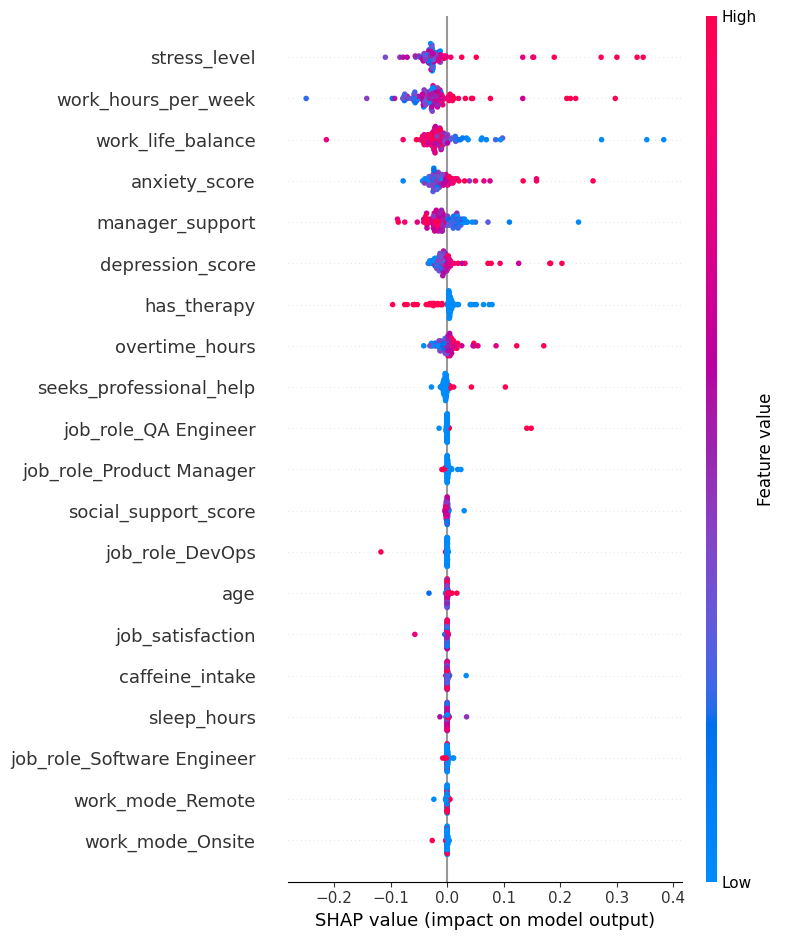

In [ ]:
import shap

explainer_final = shap.Explainer(stack.predict, background_sample)
shap_values_final = explainer_final(X_test_scaled[:100])

shap.summary_plot(
    shap_values_final,
    X_test[:100],
    feature_names=X.columns.tolist()
)

/tmp/ipykernel_3672/668183423.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_scores.values()), y=list(sorted_scores.keys()), palette="viridis")


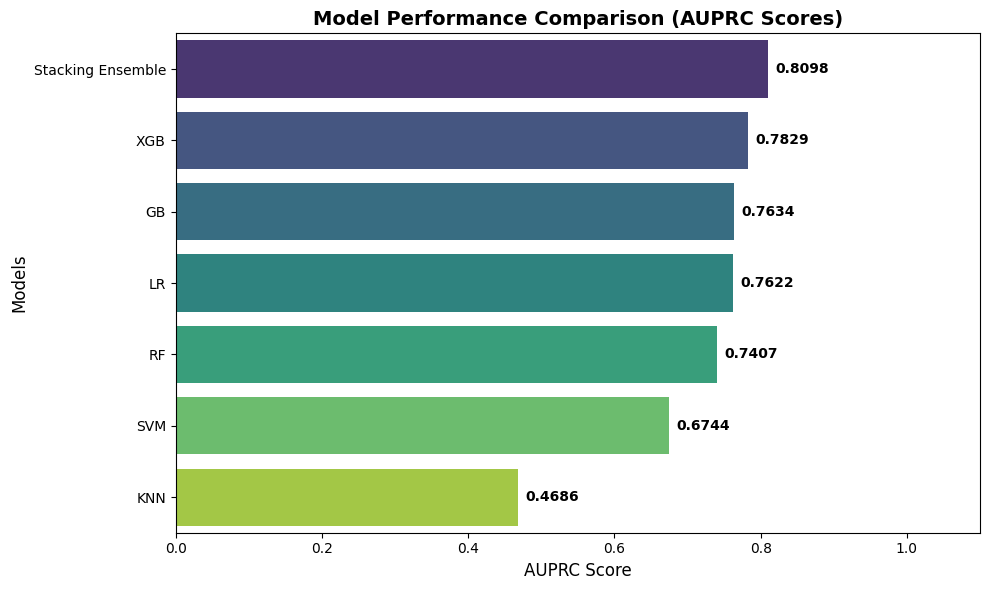

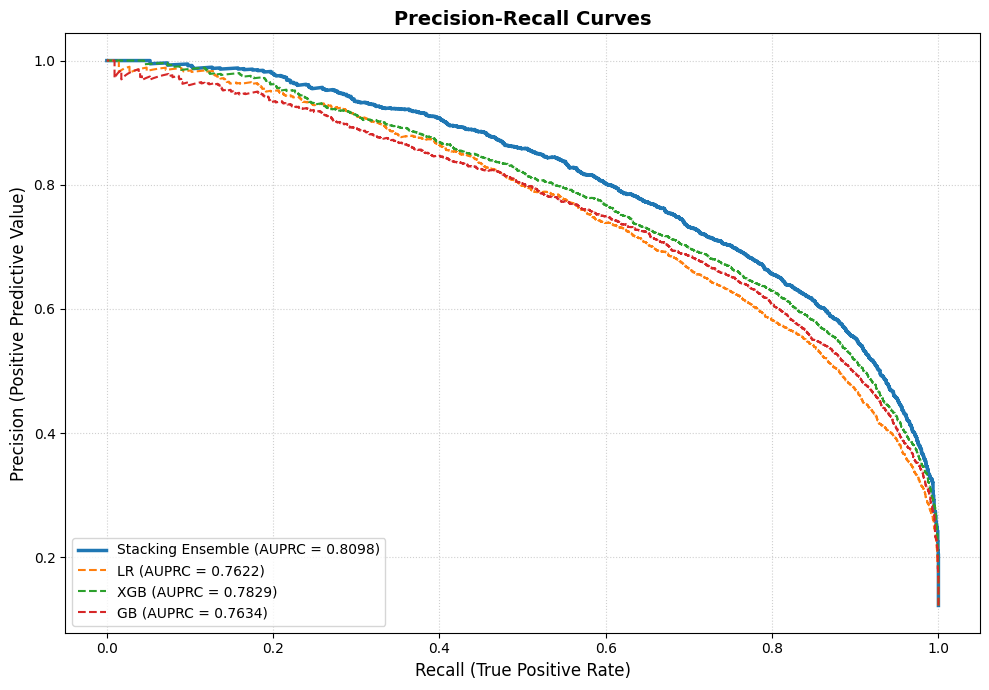

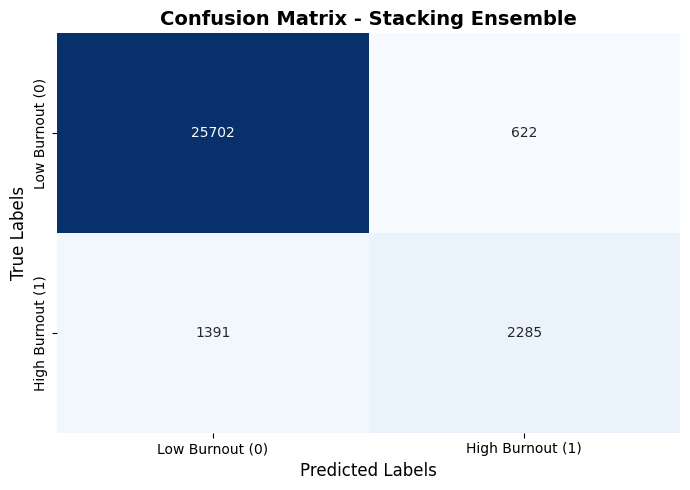

PermutationExplainer explainer: 101it [00:25,  3.06it/s]
/tmp/ipykernel_3672/668183423.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


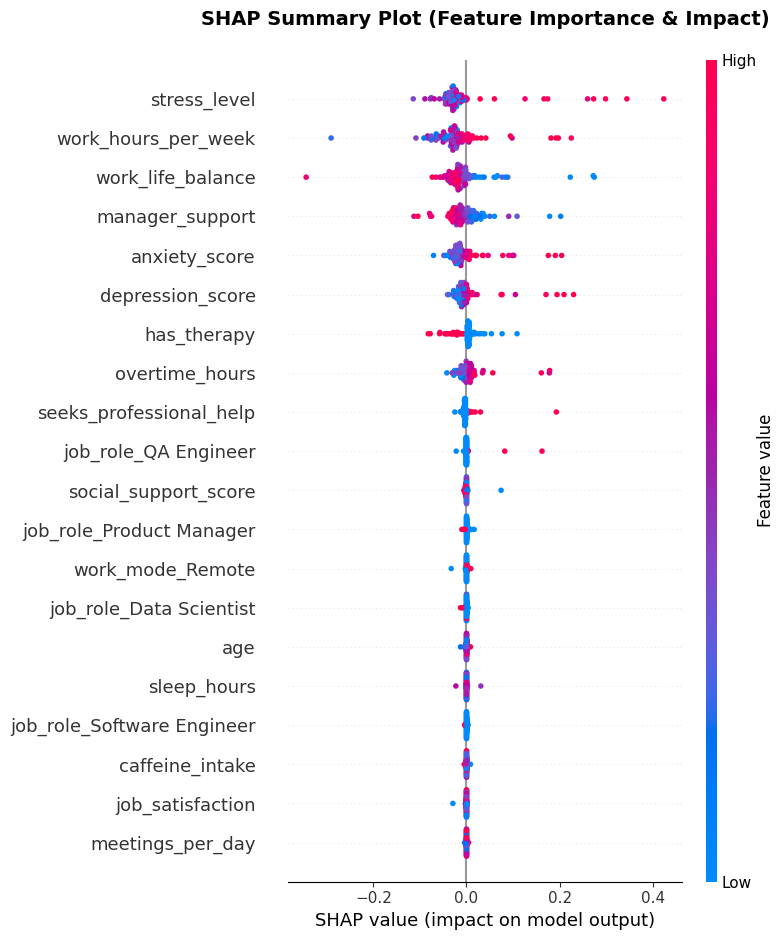

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import precision_recall_curve, confusion_matrix

# =====================================================================
# 1. MODEL PERFORMANCE COMPARISON PLOT (AUPRC BAR CHART)
# =====================================================================
all_scores = {**model_scores, "Stacking Ensemble": final_auprc}
sorted_scores = dict(sorted(all_scores.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(sorted_scores.values()), y=list(sorted_scores.keys()), palette="viridis")
plt.title("Model Performance Comparison (AUPRC Scores)", fontsize=14, fontweight='bold')
plt.xlabel("AUPRC Score", fontsize=12)
plt.ylabel("Models", fontsize=12)
plt.xlim(0, 1.1)

for i, v in enumerate(sorted_scores.values()):
    plt.text(v + 0.01, i, f"{v:.4f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# =====================================================================
# 2. PRECISION-RECALL CURVES (FOR ENSEMBLE AND TOP MODELS)
# =====================================================================
plt.figure(figsize=(10, 7))

# Plot for Stacking Ensemble
precision_ens, recall_ens, _ = precision_recall_curve(y_test, ensemble_probs)
plt.plot(recall_ens, precision_ens, label=f"Stacking Ensemble (AUPRC = {final_auprc:.4f})", linewidth=2.5)

# Plot for individual top models
for name in top_models:
    probs = selected_models[name].predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=f"{name} (AUPRC = {model_scores[name]:.4f})", linestyle="--")

plt.title("Precision-Recall Curves", fontsize=14, fontweight='bold')
plt.xlabel("Recall (True Positive Rate)", fontsize=12)
plt.ylabel("Precision (Positive Predictive Value)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


# =====================================================================
# 3. CONFUSION MATRIX PLOT (FOR STACKING ENSEMBLE)
# =====================================================================
ensemble_preds = stack.predict(X_test_scaled)
cm = confusion_matrix(y_test, ensemble_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Low Burnout (0)", "High Burnout (1)"],
            yticklabels=["Low Burnout (0)", "High Burnout (1)"])
plt.title("Confusion Matrix - Stacking Ensemble", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.tight_layout()
plt.show()


# =====================================================================
# 4. SHAP SUMMARY PLOT (SHAPE PLOT FOR ENSEMBLE EXPLANATIONS)
# =====================================================================
explainer_final = shap.Explainer(stack.predict, background_sample)
shap_values_final = explainer_final(X_test_scaled[:100])

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_final,
    X_test[:100],
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot (Feature Importance & Impact)", fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()